# AI for Radiologic Image Tasks - *Mastering Artificial Intelligence in Radiology*
## Segmentation

This notebook introduces a complete, educational workflow for training a lung segmentation model on chest X-ray images. The task is to predict a binary mask that marks the lung pixels in each image.

The notebook uses the NLM Montgomery dataset. Each chest radiograph is paired with manual left-lung and right-lung masks. We combine those two masks into one binary lung mask, then train a ResNet34 U-Net to predict that mask from the image.

The main steps are:

1. Build an image index with image paths, mask paths, and readable disease labels.
2. Load chest X-ray images and combine left-lung and right-lung masks.
3. Create a stratified train/validation split from the Montgomery images.
4. Prepare PyTorch datasets and loaders, including mask-aware image augmentation.
5. Define a ResNet34 U-Net for pixel-level lung segmentation.
6. Train the model while tracking loss, Dice score, and intersection-over-union.
7. Preview ground-truth masks beside model predictions on validation images.

The goal is not to build a production-ready medical segmentation system. Instead, the notebook is meant to show the core logic behind segmentation: pair each image with a pixel-level target, keep images and masks aligned during preprocessing, train a model to predict one value per pixel, and evaluate whether the predicted anatomy overlaps the manual annotation.


## 0. Setup

This section imports the libraries, fixes the random seed for repeatable results, defines the Montgomery dataset folders, and selects the compute device.

Before running the notebook, replace `DATASET_DIR` in the code cell below with the location of the Montgomery dataset on your own environment. The notebook expects the dataset directory to contain a `CXR_png` folder and the two manual-mask folders `ManualMask/leftMask` and `ManualMask/rightMask`.


In [ ]:
from collections import OrderedDict
from pathlib import Path
import random
import warnings

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams["figure.figsize"] = (8, 8)
plt.rcParams["image.cmap"] = "gray"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DATASET_DIR = Path("datasets/NLM-MontgomeryCXRSet/MontgomerySet")
IMAGE_DIR = DATASET_DIR / "CXR_png"
LEFT_MASK_DIR = DATASET_DIR / "ManualMask" / "leftMask"
RIGHT_MASK_DIR = DATASET_DIR / "ManualMask" / "rightMask"
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

assert IMAGE_DIR.exists(), f"Image directory not found: {IMAGE_DIR}"
assert LEFT_MASK_DIR.exists(), f"Left-mask directory not found: {LEFT_MASK_DIR}"
assert RIGHT_MASK_DIR.exists(), f"Right-mask directory not found: {RIGHT_MASK_DIR}"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {DEVICE}")

## 1. Build Image And Mask Index

Here we create a simple table with one row per image. Each row stores the image ID, image path, left-mask path, right-mask path, numeric disease label, and readable label name. This table becomes the source of truth for both the image pixels and the manual segmentation masks used later in the notebook.

The disease label is not used as the segmentation target. It is kept so the train/validation split can preserve a similar TB / No TB proportion in both groups, matching the audience-facing split logic used in the classification and detection notebooks.


In [2]:
def disease_label_from_id(image_id: str) -> int:
    return int(image_id.rsplit("_", 1)[-1])


def build_montgomery_index() -> pd.DataFrame:
    rows = []
    for image_path in sorted(IMAGE_DIR.glob("*.png")):
        left_mask_path = LEFT_MASK_DIR / image_path.name
        right_mask_path = RIGHT_MASK_DIR / image_path.name
        if not left_mask_path.exists() or not right_mask_path.exists():
            continue
        image_id = image_path.stem
        rows.append({
            "ImageId": image_id,
            "image_path": image_path,
            "left_mask_path": left_mask_path,
            "right_mask_path": right_mask_path,
            "disease_label": disease_label_from_id(image_id),
        })
    return pd.DataFrame(rows)


images_df = build_montgomery_index()
assert not images_df.empty, "No complete image/left-mask/right-mask triplets found."
print(f"paired images: {len(images_df):,}")
images_df["disease_label"].value_counts().rename({0: "normal", 1: "abnormal"})

paired images: 138


disease_label
normal      80
abnormal    58
Name: count, dtype: int64

## 2. Image And Mask Loading

This section reads Montgomery chest X-ray images and their manual lung masks. The image files are loaded as grayscale arrays, and the left-lung and right-lung masks are combined into one binary mask.

A binary mask stores one target value per pixel: background pixels are 0, and lung pixels are 1. This makes segmentation more detailed than classification or box detection because the model must learn the approximate shape and boundary of the lung fields.


In [3]:
def read_grayscale_png(path: Path) -> np.ndarray:
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(path)
    return image


def normalize_percentile(image: np.ndarray, lower: float = 1, upper: float = 99, eps: float = 1e-7) -> np.ndarray:
    image = image.astype(np.float32)
    lo, hi = np.percentile(image, [lower, upper])
    image = np.clip(image, lo, hi)
    return ((image - lo) / (hi - lo + eps)).astype(np.float32)


def lung_mask(row: pd.Series) -> np.ndarray:
    left = read_grayscale_png(row.left_mask_path) > 0
    right = read_grayscale_png(row.right_mask_path) > 0
    return (left | right).astype(np.uint8)


def image_and_mask(image_id: str) -> tuple[np.ndarray, np.ndarray]:
    row = images_df.loc[images_df["ImageId"] == image_id].iloc[0]
    image = read_grayscale_png(row.image_path)
    mask = lung_mask(row)
    return image, mask

The next cell displays one Montgomery image, its combined lung mask, and an overlay of that mask on the image. This is a quick sanity check that the manual masks are aligned with the visible lung fields before model training starts.


sample ImageId: MCUCXR_0150_1
image shape: (4892, 4020)
mask positive pixels: 5,896,915


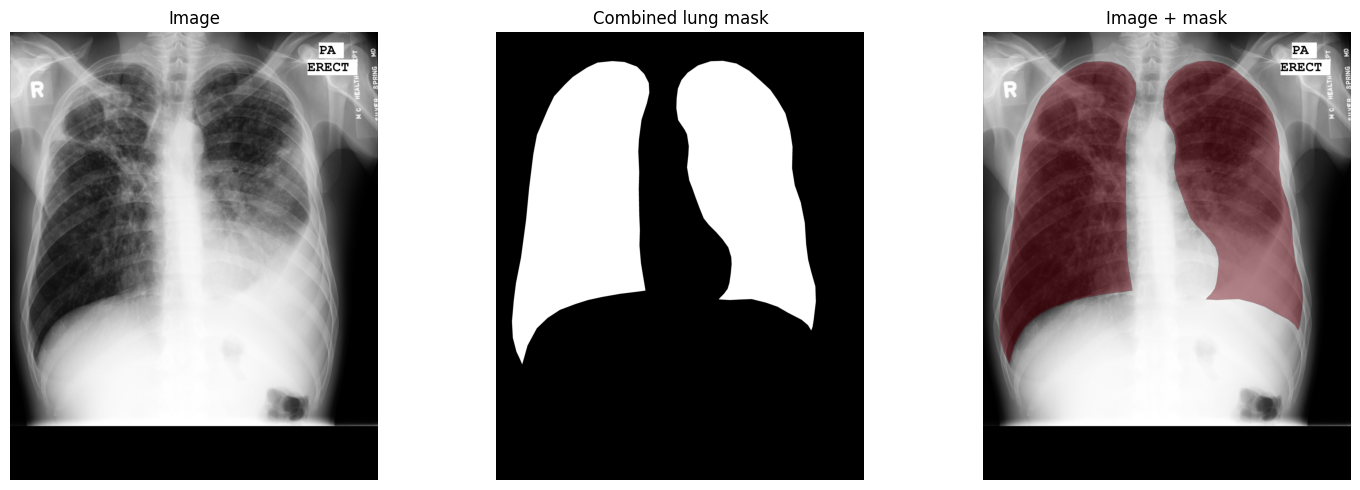

In [4]:
sample_row = images_df.sample(1, random_state=SEED).iloc[0]
sample_image = read_grayscale_png(sample_row.image_path)
sample_mask = lung_mask(sample_row)

print(f"sample ImageId: {sample_row.ImageId}")
print(f"image shape: {sample_image.shape}")
print(f"mask positive pixels: {int(sample_mask.sum()):,}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(normalize_percentile(sample_image), cmap="gray")
axes[0].set_title("Image")
axes[1].imshow(sample_mask, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Combined lung mask")
axes[2].imshow(normalize_percentile(sample_image), cmap="gray")
axes[2].imshow(np.ma.masked_where(sample_mask == 0, sample_mask), alpha=0.45, cmap="Reds", vmin=0, vmax=1)
axes[2].set_title("Image + mask")
for ax in axes:
    ax.axis("off")
plt.tight_layout()

## 3. Train/Validation Split

The Montgomery dataset is divided into two internal groups before training:

- **Training split:** 80% of the images, used to update the model weights.
- **Validation split:** 20% of the images, kept separate and used to monitor performance during training.

The split is **stratified by disease label**, meaning the notebook preserves a similar TB / No TB proportion in both groups. The model is learning lung boundaries rather than TB classification, but stratification still helps avoid putting most abnormal examples in only one split.

This validation split gives us a held-out check on the same dataset source. It helps answer whether the segmenter learned a reusable lung-shape pattern instead of memorizing the exact training images.


In [5]:
def stratified_image_split(df: pd.DataFrame, valid_fraction: float = 0.2, seed: int = SEED):
    rng = np.random.default_rng(seed)
    train_ids, valid_ids = [], []
    for _, group in df.groupby("disease_label"):
        ids = group["ImageId"].to_numpy().copy()
        rng.shuffle(ids)
        n_valid = max(1, int(round(len(ids) * valid_fraction)))
        valid_ids.extend(ids[:n_valid])
        train_ids.extend(ids[n_valid:])
    train_ids = np.array(train_ids)
    valid_ids = np.array(valid_ids)
    rng.shuffle(train_ids)
    rng.shuffle(valid_ids)
    return train_ids, valid_ids


train_ids, valid_ids = stratified_image_split(images_df)
label_lookup = images_df.set_index("ImageId")["disease_label"]
pd.DataFrame({
    "split": ["all", "train", "valid"],
    "images": [len(images_df), len(train_ids), len(valid_ids)],
    "abnormal_fraction": [
        images_df["disease_label"].mean(),
        label_lookup.loc[train_ids].mean(),
        label_lookup.loc[valid_ids].mean(),
    ],
})

,split,images,abnormal_fraction
0,all,138,0.420290
1,train,110,0.418182
2,valid,28,0.428571


## 4. PyTorch Segmentation Dataset

This section prepares images and masks for the model by defining the transformations and the custom PyTorch dataset class.

Data augmentation is more delicate for segmentation than for classification. If an image is shifted, scaled, rotated, or flipped, the mask must be transformed in the same way. Otherwise, the pixels marked as lung would no longer match the lung pixels in the image.

In this notebook, the training images use these augmentation techniques:

1. Resize: makes every image and mask the same input size for the neural network.
2. Shift, scale, and rotation: slightly moves, zooms, or rotates the image and mask together.
3. Horizontal flip: mirrors the image and mask together.

Validation images are not randomly augmented. They are only resized, so validation loss, Dice score, and IoU are consistent and easier to interpret.


In [6]:
def make_train_transform(size: int) -> A.Compose:
    return A.Compose([
        A.Resize(height=size, width=size),
        A.ShiftScaleRotate(
            shift_limit=0.03,
            scale_limit=0.08,
            rotate_limit=7,
            p=0.5,
            border_mode=cv2.BORDER_CONSTANT,
        ),
        A.HorizontalFlip(p=0.5),
    ])


def make_valid_transform(size: int) -> A.Compose:
    return A.Compose([
        A.Resize(height=size, width=size),
    ])


class MontgomeryLungDataset(Dataset):
    def __init__(self, image_ids, metadata: pd.DataFrame, transform: A.Compose | None = None):
        self.image_ids = list(image_ids)
        self.metadata = metadata.set_index("ImageId")
        self.transform = transform

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        row = self.metadata.loc[image_id]
        image = normalize_percentile(read_grayscale_png(row.image_path))
        mask = lung_mask(row).astype(np.float32)

        if self.transform is not None:
            transformed = self.transform(image=image, mask=mask)
            image = transformed["image"].astype(np.float32)
            mask = transformed["mask"].astype(np.float32)

        image = np.repeat(image[..., None], 3, axis=-1)
        image = (image - IMAGENET_MEAN) / IMAGENET_STD

        image = np.ascontiguousarray(image.transpose(2, 0, 1))
        mask = np.ascontiguousarray((mask > 0.5).astype(np.float32)[None, ...])

        image = torch.from_numpy(image)
        mask = torch.from_numpy(mask)
        return image, mask, image_id

In the next cell, we use the dataset class defined above and choose the main data-loading settings for this project.

`IMAGE_SIZE` defines the standard image size used by the model. `BATCH_SIZE` controls how many image-mask pairs are processed at once. `NUM_WORKERS` controls how many background processes help load the data.


In [7]:
IMAGE_SIZE = 512
BATCH_SIZE = 8
NUM_WORKERS = 4

# Keep these non-None for quick CPU smoke tests. Set to None for full training.
MAX_TRAIN_IMAGES = None
MAX_VALID_IMAGES = None

train_transform = make_train_transform(IMAGE_SIZE)
valid_transform = make_valid_transform(IMAGE_SIZE)

train_ids_run = train_ids[:MAX_TRAIN_IMAGES] if MAX_TRAIN_IMAGES else train_ids
valid_ids_run = valid_ids[:MAX_VALID_IMAGES] if MAX_VALID_IMAGES else valid_ids

train_ds = MontgomeryLungDataset(train_ids_run, images_df, transform=train_transform)
valid_ds = MontgomeryLungDataset(valid_ids_run, images_df, transform=valid_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

images, masks, image_ids = next(iter(train_loader))
images.shape, masks.shape, image_ids[:2]

(torch.Size([8, 3, 512, 512]),
 torch.Size([8, 1, 512, 512]),
 (np.str_('MCUCXR_0311_1'), np.str_('MCUCXR_0011_0')))

The next cell shows how mask-aware augmentation changes a training example. The first column displays the resized image and mask without random augmentation, and the other columns show augmented versions created from the same original image with the mask transformed alongside it.


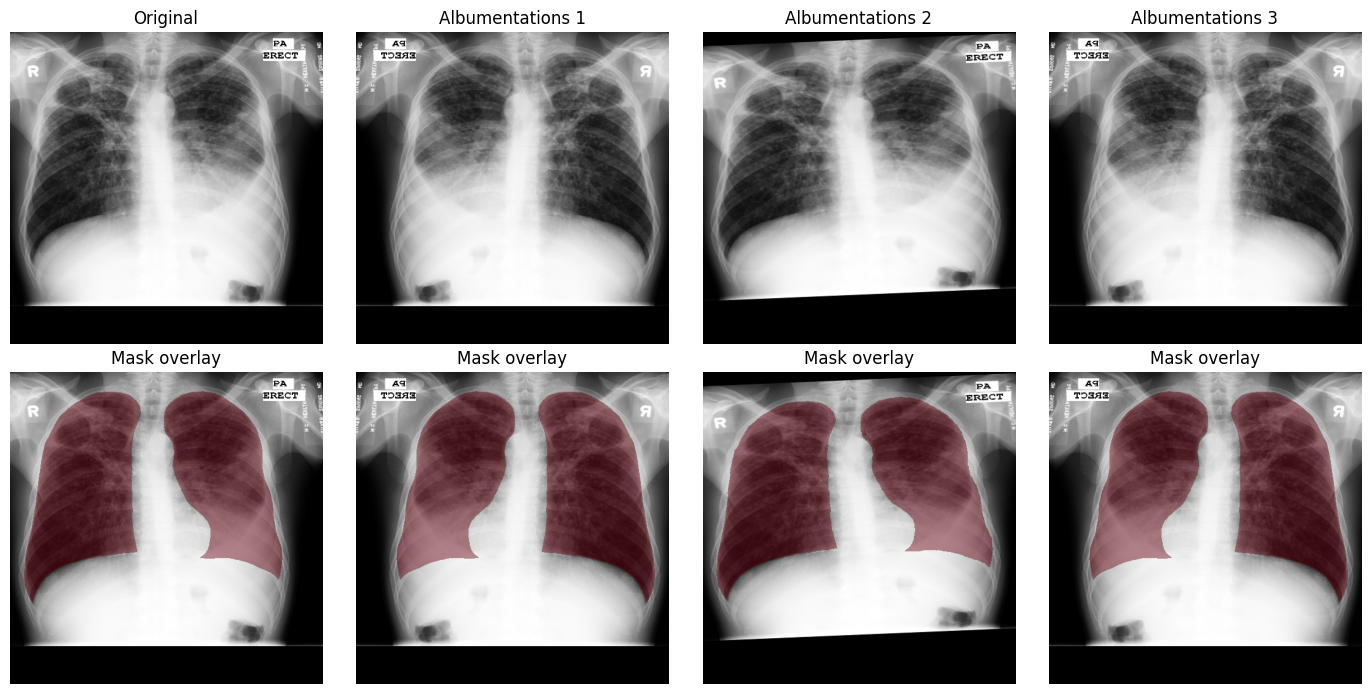

In [8]:
preview_id = sample_row.ImageId
preview_image, preview_mask = image_and_mask(preview_id)
preview_image = normalize_percentile(preview_image).astype(np.float32)
preview_mask = preview_mask.astype(np.float32)

base = valid_transform(image=preview_image, mask=preview_mask)
base_image, base_mask = base["image"], base["mask"]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for col in range(4):
    if col == 0:
        image_aug, mask_aug = base_image, base_mask
        title = "Original"
    else:
        augmented = train_transform(image=preview_image, mask=preview_mask)
        image_aug, mask_aug = augmented["image"], augmented["mask"]
        title = f"Albumentations {col}"

    axes[0, col].imshow(image_aug, cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title(title)
    axes[1, col].imshow(image_aug, cmap="gray", vmin=0, vmax=1)
    axes[1, col].imshow(np.ma.masked_where(mask_aug == 0, mask_aug), alpha=0.45, cmap="Reds", vmin=0, vmax=1)
    axes[1, col].set_title("Mask overlay")

for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()

## 5. Teaching Point

Segmentation changes the label from one value per image to one value per pixel. In classification, the target can be written as **TB** or **No TB**. In segmentation, every pixel has its own target: **lung** or **background**.

### The mask is part of the data, not just metadata.

A mask is spatially tied to the image. If the image is resized, the mask must be resized. If the image is flipped, the mask must be flipped. If the image is rotated, the mask must rotate with it. The model only learns a useful anatomy boundary when those two arrays stay aligned.

This is why the transform pipeline receives both `image` and `mask`, and why validation uses deterministic preprocessing. The training examples can vary, but the relationship between the radiograph and its lung mask must remain correct.

**Takeaway:** segmentation is dense supervision. The model is not only deciding whether something is present; it is learning where each relevant pixel belongs.


## 6. ResNet34 U-Net

This section defines a U-Net-style segmentation model with a ResNet34 encoder. The encoder compresses the image into increasingly abstract feature maps, and the decoder upsamples those features back to the original mask resolution.

The model outputs one logit per pixel. Higher logits mean the model is more confident that the pixel belongs to lung tissue. During training, the logits are compared with the binary mask; during visualization, the logits are converted into probabilities and thresholded into a predicted mask.

This architecture is useful for teaching segmentation because it shows the key idea clearly: combine high-level context from deep layers with spatial detail from earlier layers to recover a dense pixel-level prediction.


In [17]:
RESNET34_URL = "https://download.pytorch.org/models/resnet34-b627a593.pth"


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes: int, planes: int, stride: int = 1, downsample: nn.Module | None = None):
        super().__init__()
        self.conv1 = nn.Conv2d(inplanes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        return self.relu(out)


class ResNet34Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.inplanes = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(64, 3)
        self.layer2 = self._make_layer(128, 4, stride=2)
        self.layer3 = self._make_layer(256, 6, stride=2)
        self.layer4 = self._make_layer(512, 3, stride=2)

    def _make_layer(self, planes: int, blocks: int, stride: int = 1):
        downsample = None
        if stride != 1 or self.inplanes != planes:
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes),
            )
        layers = [BasicBlock(self.inplanes, planes, stride, downsample)]
        self.inplanes = planes
        layers.extend(BasicBlock(self.inplanes, planes) for _ in range(1, blocks))
        return nn.Sequential(*layers)

    def load_imagenet_weights(self):
        state_dict = torch.hub.load_state_dict_from_url(RESNET34_URL, map_location="cpu", progress=True)
        encoder_state = OrderedDict((key, value) for key, value in state_dict.items() if not key.startswith("fc."))
        self.load_state_dict(encoder_state, strict=True)

    def forward(self, x):
        x0 = x
        x1 = self.relu(self.bn1(self.conv1(x)))
        x2 = self.maxpool(x1)
        x2 = self.layer1(x2)
        x3 = self.layer2(x2)
        x4 = self.layer3(x3)
        x5 = self.layer4(x4)
        return x0, x1, x2, x3, x4, x5


class DecoderBlock(nn.Module):
    def __init__(self, in_channels: int, skip_channels: int, out_channels: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels + skip_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x, skip):
        x = F.interpolate(x, size=skip.shape[2:], mode="bilinear", align_corners=False)
        x = torch.cat([x, skip], dim=1)
        return self.block(x)


class ResNet34UNet(nn.Module):
    def __init__(self, out_channels: int = 1, pretrained: bool = True):
        super().__init__()
        self.encoder = ResNet34Encoder()
        if pretrained:
            self.encoder.load_imagenet_weights()
        self.decoder4 = DecoderBlock(512, 256, 256)
        self.decoder3 = DecoderBlock(256, 128, 128)
        self.decoder2 = DecoderBlock(128, 64, 64)
        self.decoder1 = DecoderBlock(64, 64, 32)
        self.decoder0 = DecoderBlock(32, 3, 32)
        self.final_conv = nn.Conv2d(32, out_channels, kernel_size=1)

    def forward(self, x):
        x0, x1, x2, x3, x4, x5 = self.encoder(x)
        x = self.decoder4(x5, x4)
        x = self.decoder3(x, x3)
        x = self.decoder2(x, x2)
        x = self.decoder1(x, x1)
        x = self.decoder0(x, x0)
        return self.final_conv(x)


The next cell creates the model and runs a small smoke test. The output shape should have one channel per image, representing the raw lung-mask logit at each pixel.


In [18]:
PRETRAINED_ENCODER = True

model = ResNet34UNet(pretrained=PRETRAINED_ENCODER).to(DEVICE)
with torch.no_grad():
    test_logits = model(images[:2].to(DEVICE))
test_logits.shape

torch.Size([2, 1, 512, 512])

## 7. Train

Training repeatedly shows image-and-mask batches to the model, measures prediction error, and updates the model weights. The notebook tracks three quantities:

- **Segmentation loss:** a combination of binary cross-entropy and Dice loss used for optimization.
- **Dice score:** an overlap score that emphasizes agreement between predicted and target lung pixels.
- **Intersection-over-union (IoU):** another overlap score between the predicted mask and the ground-truth mask.

Higher Dice and IoU values mean the predicted masks overlap the manual masks more closely. The best checkpoint is selected by validation loss, while Dice and IoU make localization quality easier to interpret.


In [19]:
def segmentation_scores_from_logits(logits: torch.Tensor, targets: torch.Tensor, threshold: float = 0.5, eps: float = 1e-7) -> dict[str, torch.Tensor]:
    preds = (torch.sigmoid(logits) > threshold).float()
    dims = tuple(range(1, preds.ndim))
    intersection = (preds * targets).sum(dim=dims)
    pred_area = preds.sum(dim=dims)
    target_area = targets.sum(dim=dims)
    union = pred_area + target_area - intersection

    dice_per_image = (2 * intersection + eps) / (pred_area + target_area + eps)
    iou_per_image = (intersection + eps) / (union + eps)

    return {
        "dice": dice_per_image.mean(),
        "iou": iou_per_image.mean(),
    }


def dice_loss_from_logits(logits: torch.Tensor, targets: torch.Tensor, eps: float = 1e-7) -> torch.Tensor:
    probs = torch.sigmoid(logits)
    dims = tuple(range(1, probs.ndim))
    intersection = (probs * targets).sum(dim=dims)
    denominator = probs.sum(dim=dims) + targets.sum(dim=dims)
    dice = (2 * intersection + eps) / (denominator + eps)
    return 1 - dice.mean()


bce_loss = nn.BCEWithLogitsLoss()


def segmentation_loss(logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    return bce_loss(logits, targets) + dice_loss_from_logits(logits, targets)

The next cell defines the shared epoch loop used for both training and validation. When an optimizer is provided, the model updates its weights. Without an optimizer, the same loop runs in evaluation mode and only records metrics.


In [20]:
def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    totals = {"loss": 0.0, "dice": 0.0, "iou": 0.0}
    total_batches = 0

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for images, masks, _ in tqdm(loader, leave=False):
            images = images.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)

            logits = model(images)
            loss = segmentation_loss(logits, masks)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

            scores = segmentation_scores_from_logits(logits, masks)
            totals["loss"] += loss.item()
            totals["dice"] += scores["dice"].item()
            totals["iou"] += scores["iou"].item()
            total_batches += 1

    return {key: value / total_batches for key, value in totals.items()}

The next cell is the actual training loop. It sets the number of epochs, learning-rate schedule, checkpoint path, and optimizer. Each epoch trains on the Montgomery training split, evaluates on the validation split, records loss and overlap metrics, saves the best checkpoint by validation loss, advances the scheduler, and prints a compact progress summary.


In [21]:
EPOCHS = 10
LEARNING_RATE = 1e-3
MIN_LEARNING_RATE = 1e-5
CHECKPOINT_PATH = RESULTS_DIR / "resnet34_unet_montgomery_lung.pt"

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=MIN_LEARNING_RATE)
history = []
best_valid_loss = float("inf")

for epoch in range(1, EPOCHS + 1):
    train_metrics = run_epoch(model, train_loader, optimizer)
    valid_metrics = run_epoch(model, valid_loader)
    current_lr = optimizer.param_groups[0]["lr"]
    history.append({"epoch": epoch, "lr": current_lr, **{f"train_{k}": v for k, v in train_metrics.items()}, **{f"valid_{k}": v for k, v in valid_metrics.items()}})

    if valid_metrics["loss"] < best_valid_loss:
        best_valid_loss = valid_metrics["loss"]
        torch.save({
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "history": history,
            "image_size": IMAGE_SIZE,
        }, CHECKPOINT_PATH)

    scheduler.step()

    print(
        f"epoch {epoch:02d} lr {current_lr:.2e} | "
        f"train loss {train_metrics['loss']:.4f} dice {train_metrics['dice']:.4f} iou {train_metrics['iou']:.4f} | "
        f"valid loss {valid_metrics['loss']:.4f} dice {valid_metrics['dice']:.4f} iou {valid_metrics['iou']:.4f}"
    )
pd.DataFrame(history)

epoch 01 lr 1.00e-03 | train loss 0.8958 dice 0.8147 iou 0.7217 | valid loss 1.8631 dice 0.3475 iou 0.2210


epoch 02 lr 9.76e-04 | train loss 0.6435 dice 0.9513 iou 0.9081 | valid loss 0.5872 dice 0.9214 iou 0.8573


epoch 03 lr 9.05e-04 | train loss 0.5604 dice 0.9613 iou 0.9261 | valid loss 0.5395 dice 0.9555 iou 0.9177


epoch 04 lr 7.96e-04 | train loss 0.4954 dice 0.9670 iou 0.9368 | valid loss 0.4712 dice 0.9647 iou 0.9330


epoch 05 lr 6.58e-04 | train loss 0.4443 dice 0.9704 iou 0.9429 | valid loss 0.4658 dice 0.9680 iou 0.9391


...

epoch 07 lr 3.52e-04 | train loss 0.3818 dice 0.9750 iou 0.9516 | valid loss 0.4095 dice 0.9728 iou 0.9474


epoch 08 lr 2.14e-04 | train loss 0.3637 dice 0.9768 iou 0.9549 | valid loss 0.3821 dice 0.9744 iou 0.9513


epoch 09 lr 1.05e-04 | train loss 0.3527 dice 0.9786 iou 0.9584 | valid loss 0.3754 dice 0.9745 iou 0.9515


epoch 10 lr 3.42e-05 | train loss 0.3473 dice 0.9790 iou 0.9591 | valid loss 0.3665 dice 0.9751 iou 0.9524


,epoch,lr,train_loss,train_dice,train_iou,valid_loss,valid_dice,valid_iou
0,1,0.001000,0.895839,0.814726,0.721659,1.863113,0.347457,0.220967
1,2,0.000976,0.643517,0.951308,0.908082,0.587199,0.921400,0.857336
2,3,0.000905,0.560385,0.961331,0.926107,0.539458,0.955468,0.917697
3,4,0.000796,0.495404,0.966995,0.936811,0.471248,0.964714,0.932967
4,5,0.000658,0.444256,0.970410,0.942948,0.465805,0.967979,0.939129
5,6,0.000505,0.411765,0.972335,0.946522,0.418173,0.972214,0.946807
6,7,0.000352,0.381770,0.975039,0.951635,0.409464,0.972780,0.947406
7,8,0.000214,0.363718,0.976795,0.954897,0.382128,0.974428,0.951295
8,9,0.000105,0.352707,0.978638,0.958369,0.375381,0.974532,0.951461
9,10,0.000034,0.347342,0.979015,0.959092,0.366519,0.975068,0.952403


## 8. Validate And Preview Predictions

After training, the trained model is used to predict lung masks on held-out validation images. The preview plots each image with its ground-truth mask and predicted mask so the model output can be inspected visually.

This visual check is important because aggregate Dice and IoU scores do not show the full failure mode. A model can have a reasonable average score while still missing an apex, leaking outside the thorax, or producing rough boundaries on individual images. Looking at examples helps connect the metric back to the anatomy.


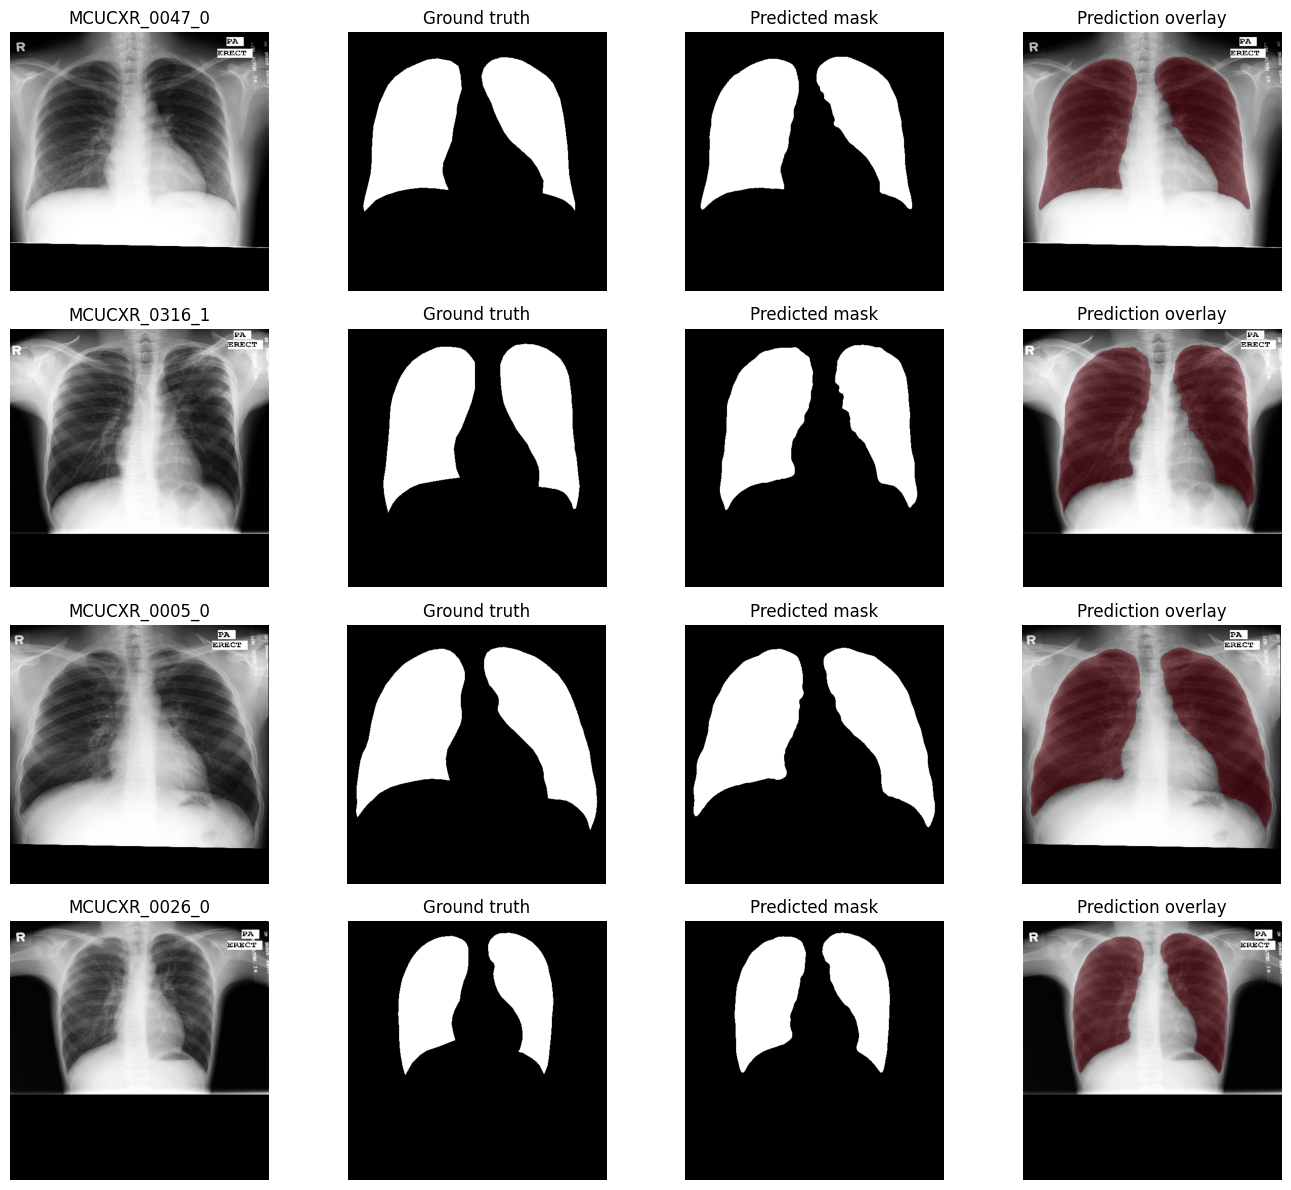

In [22]:
def predict_batch(model, images: torch.Tensor, threshold: float = 0.5) -> tuple[np.ndarray, np.ndarray]:
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(images.to(DEVICE))).cpu().numpy()
    return (probs > threshold).astype(np.uint8), probs


preview_valid_ids = valid_ids[:max(BATCH_SIZE, 4)]
preview_valid_ds = MontgomeryLungDataset(preview_valid_ids, images_df, transform=valid_transform)
preview_valid_loader = DataLoader(
    preview_valid_ds,
    batch_size=min(BATCH_SIZE, len(preview_valid_ds)),
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

images, masks, image_ids = next(iter(preview_valid_loader))
pred_masks, pred_probs = predict_batch(model, images)

n = min(4, images.shape[0])
fig, axes = plt.subplots(n, 4, figsize=(14, 3 * n))
if n == 1:
    axes = axes[None, :]

for i in range(n):
    display_image = images[i].numpy().transpose(1, 2, 0)
    display_image = np.clip(display_image * IMAGENET_STD + IMAGENET_MEAN, 0, 1)
    display_image = display_image[..., 0]

    axes[i, 0].imshow(display_image, cmap="gray", vmin=0, vmax=1)
    axes[i, 0].set_title(str(image_ids[i])[:32])
    axes[i, 1].imshow(masks[i, 0], cmap="gray", vmin=0, vmax=1)
    axes[i, 1].set_title("Ground truth")
    axes[i, 2].imshow(pred_masks[i, 0], cmap="gray", vmin=0, vmax=1)
    axes[i, 2].set_title("Predicted mask")
    axes[i, 3].imshow(display_image, cmap="gray", vmin=0, vmax=1)
    axes[i, 3].imshow(np.ma.masked_where(pred_masks[i, 0] == 0, pred_masks[i, 0]), alpha=0.45, cmap="Reds", vmin=0, vmax=1)
    axes[i, 3].set_title("Prediction overlay")
    for ax in axes[i]:
        ax.axis("off")
plt.tight_layout()

The final cell plots the training history. The loss curve shows whether optimization improved over time, the Dice and IoU curves show mask-overlap quality, and the learning-rate plot shows the cosine schedule used during training.


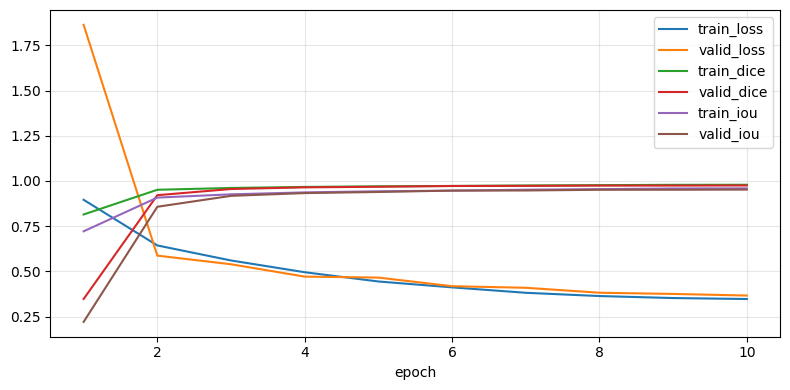

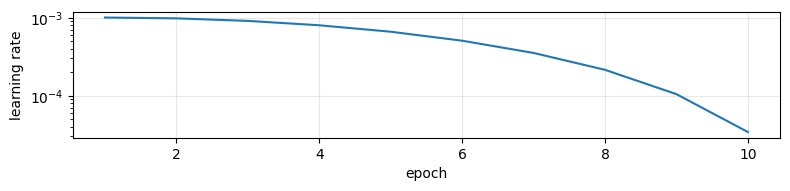

In [23]:
history_df = pd.DataFrame(history)
history_df.plot(x="epoch", y=["train_loss", "valid_loss", "train_dice", "valid_dice", "train_iou", "valid_iou"], figsize=(8, 4))
plt.grid(True, alpha=0.3)
plt.tight_layout()

history_df.plot(x="epoch", y="lr", figsize=(8, 2), logy=True, legend=False)
plt.ylabel("learning rate")
plt.grid(True, alpha=0.3)
plt.tight_layout()